### RNN are little neural circuits with memory. The problem with RNN's are:
1. Vanishing Gradient
2. Exploding Gradient
3. Unable to handle long term dependencies

To fix this problems LSTM and GRU came into picture. They have gates (LSTM) and switches(GRU) that makes
them really useful to train models on sequence data.

In [18]:
#dataset to train models
import numpy as np
import random

x = np.linspace(0,100,500)
y = np.sin(x) + 0.1*np.random.randn(500)

#preparing sequences
def create_seq(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i: i+seq_len])
        Y.append(data[i+seq_len])
    return np.array(X), np.array(Y)

X,y = create_seq(y, seq_len=20)

#print(X.shape)  ----> (480,20) 
#print(y.shape)  ----> (480)

X = X.reshape(X.shape[0],X.shape[1],1)
y = y.reshape(-1,1)


#### LSTM Overview: It has 3 gates
1. Input gate - to write important data
2. Forget gate - to erase (0) or keep (1) past data
3. Output gate - to show the result
4. It also has a Cell state, basically a diary where all the gates performs their work.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(20,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam',loss='mse')
lstm_model.summary()

lstm_model.fit(
            X,
            y,
            epochs=20,
            batch_size = 32,
            verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3938
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0852
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0153
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0111
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0125
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0126
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0127
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0121
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0112
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0111
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0109
Epoch 16/20
15/15 ━

#### GRU on the other hand has
1. Update gate - basically input & forget gate from LSTM are merged
2. Reset gate - handles how much old info to use to compute new memory

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=False, input_shape=(20,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam',loss='mse')
gru_model.summary()

gru_model.fit(
    X,
    y,
    epochs = 20,
    verbose = 1,
    batch_size = 32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3350  
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1465
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0865
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0347
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0163
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0154
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0159
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0155
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0146
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0148
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144
Epoch 16/20
15/15

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


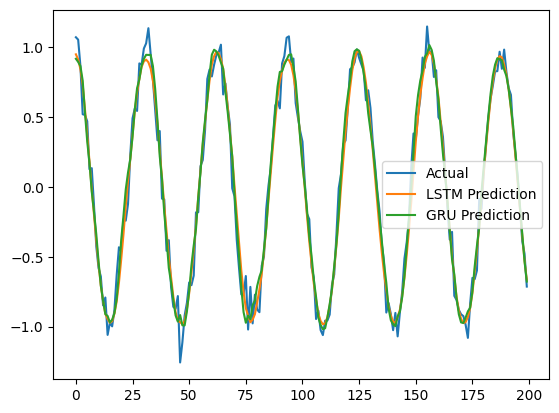

In [22]:
#predicting result and plotting the comparative graph
import matplotlib.pyplot as plt

x_test = np.linspace(0,100,200)
y_test = np.sin(x) + 0.1*np.random.randn(500)

#preparing sequences
def create_seq(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i: i+seq_len])
        Y.append(data[i+seq_len])
    return np.array(X), np.array(Y)

X_test,y_test = create_seq(y, seq_len=20)

X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)
y_test = y_test.reshape(-1,1)

y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru = gru_model.predict(X_test)

plt.plot(y_test[:200],label='Actual')
plt.plot(y_pred_lstm[:200],label='LSTM Prediction')
plt.plot(y_pred_gru[:200],label='GRU Prediction')
plt.legend()
plt.show()


RNNs forget → LSTM/GRU solve forgetting

LSTM has 3 gated powers → GRU has 2 efficient switches

LSTM = deep thoughts + diary

GRU = fast & minimalist

Both are kings of sequence tasks